# Binary Sexism Detection with NLP

<img src="news-sexisme-EN.jpg" alt="drawing" width="380"/>

## Overview

Sexism is a growing problem online. It can inflict harm on women who are targeted, make online spaces inaccessible and unwelcoming, and perpetuate social asymmetries and injustices. Automated tools are now widely deployed to find, and assess sexist content at scale but most only give classifications for generic, high-level categories, with no further explanation. Flagging what is sexist content and also explaining why it is sexist improves interpretability, trust and understanding of the decisions that automated tools use, empowering both users and moderators.

This portfolio project implements **binary sexism detection** — predicting whether a social media post is sexist or not sexist — using the [SemEval 2023 Task 10 EDOS](https://codalab.lisn.upsaclay.fr/competitions/7124#learn_the_details-overview) (Explainable Detection of Online Sexism) dataset. The work focuses on Task A (binary classification) using a 5,000-post subset of the full 20,000-instance corpus.

## Approach

The pipeline compares traditional and transformer-based NLP techniques across a full machine learning workflow:

- **Preprocessing**: Clean and normalize raw social media text (URLs, mentions, emojis, casing)
- **Feature engineering**: TF-IDF vectorization and DistilBERT contextual embeddings
- **Modeling**: Logistic Regression, Random Forest, and Support Vector Machine (SVM)
- **Evaluation**: Precision, recall, and weighted F1-score on a held-out test set (1,086 posts)

All six feature–model combinations (2 feature methods × 3 classifiers) are trained and compared in a results table. The best-performing setup is analyzed in detail with a confusion matrix.

## Tech Stack

Python · pandas · scikit-learn · Transformers (DistilBERT) · PyTorch · matplotlib · seaborn

## 1. Data Loading and Exploration

In this section, we load the dataset and perform initial exploration to understand its structure, distribution, and characteristics.


In [36]:
# Ensure required packages are installed
# Note: Use ! prefix to run shell commands in Jupyter notebooks
%pip install pandas numpy matplotlib seaborn scikit-learn emoji transformers torch tabulate


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1673, in print
    extend(render(renderable, render_options))
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1305, in render
    for render_output in iter_render:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/segment.py", line 249, in split_lines
    for segment in segments:
  File "/Library/

In [37]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [38]:
# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('edos_labelled_data.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nLabel Distribution:")
print(df['label'].value_counts())
print("\nLabel Distribution (Percentage):")
print(df['label'].value_counts(normalize=True) * 100)

print("\nSplit Distribution:")
print(df['split'].value_counts())

print("\nSample texts from each class:")
print("\n--- Sexist Example ---")
print(df[df['label'] == 'sexist']['text'].iloc[0])
print("\n--- Non-Sexist Example ---")
print(df[df['label'] == 'not sexist']['text'].iloc[0])

# Verify train/test split
train_df = df[df['split'] == 'train'].copy()
test_df = df[df['split'] == 'test'].copy()

print(f"\nTrain set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print(f"Total instances: {len(df)}")

print("\nTrain set label distribution:")
print(train_df['label'].value_counts())

print("\nTest set label distribution:")
print(test_df['label'].value_counts())


Dataset Shape: (5279, 4)

First few rows:
                  rewire_id  \
0   sexism2022_english-9609   
1  sexism2022_english-16993   
2  sexism2022_english-13149   
3  sexism2022_english-13021   
4    sexism2022_english-966   

                                                text       label  split  
0  In Nigeria, if you rape a woman, the men rape ...  not sexist  train  
1                            Then, she's a keeper. 😉  not sexist  train  
2  This is like the Metallica video where the poo...  not sexist  train  
3                                             woman?  not sexist  train  
4                     I bet she wished she had a gun  not sexist  train  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   rewire_id  5279 non-null   object
 1   text       5279 non-null   object
 2   label      5279 non-null   object
 3   split 

## 2. Data Preprocessing

Text preprocessing is crucial for cleaning social media data. We remove URLs, user mentions, emojis, and normalize the text while preserving important linguistic features for classification.


In [39]:
import emoji
import string

def preprocess_text(text):
    """
    Preprocess text by:
    1. Removing URLs and user mentions
    2. Removing emojis
    3. Lowercasing
    4. Removing extra whitespace
    5. Handling special characters
    """
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Remove URLs (patterns like [URL] or http://...)
    text = re.sub(r'\[URL\]', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Remove user mentions [USER]
    text = re.sub(r'\[USER\]', '', text)
    
    # Remove emojis
    text = emoji.replace_emoji(text, replace='')
    
    # Lowercase
    text = text.lower()
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    return text

# Apply preprocessing to train and test sets separately
print("Preprocessing train set...")
train_df['processed_text'] = train_df['text'].apply(preprocess_text)

print("Preprocessing test set...")
test_df['processed_text'] = test_df['text'].apply(preprocess_text)

# Display examples
print("\n--- Original vs Processed Examples ---")
print("\nOriginal (Sexist):")
print(train_df[train_df['label'] == 'sexist']['text'].iloc[0])
print("\nProcessed (Sexist):")
print(train_df[train_df['label'] == 'sexist']['processed_text'].iloc[0])

print("\nOriginal (Non-Sexist):")
print(train_df[train_df['label'] == 'not sexist']['text'].iloc[0])
print("\nProcessed (Non-Sexist):")
print(train_df[train_df['label'] == 'not sexist']['processed_text'].iloc[0])

# Check for empty texts after preprocessing
print(f"\nEmpty texts in train set: {train_df['processed_text'].str.len().eq(0).sum()}")
print(f"Empty texts in test set: {test_df['processed_text'].str.len().eq(0).sum()}")

# Prepare X and y for training
X_train = train_df['processed_text'].values
y_train = train_df['label'].values
X_test = test_df['processed_text'].values
y_test = test_df['label'].values

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Preprocessing train set...
Preprocessing test set...

--- Original vs Processed Examples ---

Original (Sexist):
[USER] Leg day is easy. Hot girls who wear miniskirts get asked out.

Processed (Sexist):
leg day is easy. hot girls who wear miniskirts get asked out.

Original (Non-Sexist):
In Nigeria, if you rape a woman, the men rape you back! #NSFW "In Nigeria, if you rape a woman, guys rape you back!" by [USER] [URL]

Processed (Non-Sexist):
in nigeria, if you rape a woman, the men rape you back! #nsfw "in nigeria, if you rape a woman, guys rape you back!" by

Empty texts in train set: 0
Empty texts in test set: 0

Training set size: 4193
Test set size: 1086


## 3. Feature Engineering

Two complementary methods convert preprocessed text into numerical features: TF-IDF for interpretable term-weighting and DistilBERT for contextual embeddings.


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer with unigrams and bigrams
# Important: fit only on training data to avoid test set leakage
tfidf_vectorizer = TfidfVectorizer(
    max_features=8000,  # Limit to top 8000 features
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,  # Minimum document frequency
    max_df=0.95,  # Maximum document frequency (remove very common words)
    lowercase=True,
    stop_words='english'  # Remove common English stopwords
)

print("Fitting TF-IDF vectorizer on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Transforming test data...")
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF feature matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF feature matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {X_train_tfidf.shape[1]}")
print(f"Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")


Fitting TF-IDF vectorizer on training data...
Transforming test data...
TF-IDF feature matrix shape (train): (4193, 6392)
TF-IDF feature matrix shape (test): (1086, 6392)
Number of features: 6392
Sparsity: 99.84%


### Method 2: BERT Embeddings

DistilBERT generates dense 768-dimensional vectors that capture semantic meaning beyond individual word counts.


In [41]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load pre-trained DistilBERT model and tokenizer
print("Loading DistilBERT model and tokenizer...")
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Set model to evaluation mode
model.eval()

# Move model to GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Using device: {device}")

def get_bert_embeddings(texts, batch_size=32):
    """
    Generate BERT embeddings for a list of texts using mean pooling.
    """
    embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        
        # Move to device
        encoded = {k: v.to(device) for k, v in encoded.items()}
        
        # Get embeddings (no gradient computation for efficiency)
        with torch.no_grad():
            outputs = model(**encoded)
            # Mean pooling: average all token embeddings (excluding padding)
            # outputs.last_hidden_state shape: (batch_size, seq_len, hidden_size)
            attention_mask = encoded['attention_mask']
            token_embeddings = outputs.last_hidden_state
            # Expand attention mask to match embedding dimensions
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            # Sum embeddings and divide by sum of attention mask
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            mean_pooled = sum_embeddings / sum_mask
        
        embeddings.append(mean_pooled.cpu().numpy())
    
    return np.vstack(embeddings)

print("\nGenerating BERT embeddings for training set...")
X_train_bert = get_bert_embeddings(X_train.tolist())

print("Generating BERT embeddings for test set...")
X_test_bert = get_bert_embeddings(X_test.tolist())

print(f"BERT embedding shape (train): {X_train_bert.shape}")
print(f"BERT embedding shape (test): {X_test_bert.shape}")
print(f"Embedding dimension: {X_train_bert.shape[1]}")


Loading DistilBERT model and tokenizer...
Using device: cpu

Generating BERT embeddings for training set...
Generating BERT embeddings for test set...
BERT embedding shape (train): (4193, 768)
BERT embedding shape (test): (1086, 768)
Embedding dimension: 768


## 4. Model Training and Evaluation

Three classifiers are trained on each feature representation and evaluated on the held-out test set using precision, recall, and F1-score.


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
import time

# Store results for all models
results = []

# Helper function to extract metrics from classification report
def extract_metrics(y_true, y_pred, model_name, feature_name):
    """Extract metrics from classification report and return as dictionary."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    # Get metrics for each class
    sexist_metrics = report.get('sexist', {})
    not_sexist_metrics = report.get('not sexist', {})
    weighted_metrics = report.get('weighted avg', {})
    
    return {
        'Feature + Model': f"{feature_name} + {model_name}",
        'Sexist (P)': sexist_metrics.get('precision', 0),
        'Sexist (R)': sexist_metrics.get('recall', 0),
        'Sexist (F1)': sexist_metrics.get('f1-score', 0),
        'Non-Sexist (P)': not_sexist_metrics.get('precision', 0),
        'Non-Sexist (R)': not_sexist_metrics.get('recall', 0),
        'Non-Sexist (F1)': not_sexist_metrics.get('f1-score', 0),
        'Weighted (P)': weighted_metrics.get('precision', 0),
        'Weighted (R)': weighted_metrics.get('recall', 0),
        'Weighted (F1)': weighted_metrics.get('f1-score', 0)
    }

# Model 1: Logistic Regression
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

# Logistic Regression with TF-IDF
print("\n--- Logistic Regression with TF-IDF ---")
lr_tfidf = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
start_time = time.time()
lr_tfidf.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
results.append(extract_metrics(y_test, y_pred_lr_tfidf, "Logistic Regression", "TF-IDF"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tfidf))

# Logistic Regression with BERT
print("\n--- Logistic Regression with BERT ---")
lr_bert = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
start_time = time.time()
lr_bert.fit(X_train_bert, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

y_pred_lr_bert = lr_bert.predict(X_test_bert)
results.append(extract_metrics(y_test, y_pred_lr_bert, "Logistic Regression", "BERT"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_bert))


MODEL 1: LOGISTIC REGRESSION

--- Logistic Regression with TF-IDF ---


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Training time: 3.59 seconds

Classification Report:
              precision    recall  f1-score   support

  not sexist       0.78      0.97      0.86       789
      sexist       0.77      0.28      0.41       297

    accuracy                           0.78      1086
   macro avg       0.77      0.62      0.64      1086
weighted avg       0.78      0.78      0.74      1086


--- Logistic Regression with BERT ---
Training time: 3.51 seconds

Classification Report:
              precision    recall  f1-score   support

  not sexist       0.83      0.88      0.85       789
      sexist       0.62      0.53      0.57       297

    accuracy                           0.78      1086
   macro avg       0.72      0.70      0.71      1086
weighted avg       0.77      0.78      0.78      1086



In [43]:
# Model 2: Random Forest
print("\n" + "=" * 60)
print("MODEL 2: RANDOM FOREST")
print("=" * 60)

# Random Forest with TF-IDF
print("\n--- Random Forest with TF-IDF ---")
rf_tfidf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
start_time = time.time()
rf_tfidf.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

y_pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)
results.append(extract_metrics(y_test, y_pred_rf_tfidf, "Random Forest", "TF-IDF"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tfidf))

# Random Forest with BERT
print("\n--- Random Forest with BERT ---")
rf_bert = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
start_time = time.time()
rf_bert.fit(X_train_bert, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

y_pred_rf_bert = rf_bert.predict(X_test_bert)
results.append(extract_metrics(y_test, y_pred_rf_bert, "Random Forest", "BERT"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_bert))



MODEL 2: RANDOM FOREST

--- Random Forest with TF-IDF ---
Training time: 0.14 seconds

Classification Report:
              precision    recall  f1-score   support

  not sexist       0.73      1.00      0.84       789
      sexist       0.86      0.02      0.04       297

    accuracy                           0.73      1086
   macro avg       0.79      0.51      0.44      1086
weighted avg       0.76      0.73      0.62      1086


--- Random Forest with BERT ---
Training time: 2.13 seconds

Classification Report:
              precision    recall  f1-score   support

  not sexist       0.77      0.97      0.86       789
      sexist       0.73      0.22      0.34       297

    accuracy                           0.76      1086
   macro avg       0.75      0.59      0.60      1086
weighted avg       0.76      0.76      0.71      1086



In [44]:
# Model 3: Support Vector Machine (SVM)
print("\n" + "=" * 60)
print("MODEL 3: SUPPORT VECTOR MACHINE")
print("=" * 60)

# SVM with TF-IDF
print("\n--- SVM with TF-IDF ---")
svm_tfidf = SVC(C=1.0, kernel='linear', random_state=42)
start_time = time.time()
svm_tfidf.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

y_pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)
results.append(extract_metrics(y_test, y_pred_svm_tfidf, "SVM", "TF-IDF"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_tfidf))

# SVM with BERT (may need PCA for dimensionality reduction)
print("\n--- SVM with BERT (using PCA for dimensionality reduction) ---")
# Apply PCA to reduce BERT dimensions for SVM efficiency
n_components = 100  # Reduce to 100 dimensions
pca = PCA(n_components=n_components, random_state=42)
X_train_bert_pca = pca.fit_transform(X_train_bert)
X_test_bert_pca = pca.transform(X_test_bert)
print(f"Reduced BERT dimensions: {X_train_bert_pca.shape[1]}")

svm_bert = SVC(C=1.0, kernel='linear', random_state=42)
start_time = time.time()
svm_bert.fit(X_train_bert_pca, y_train)
train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

y_pred_svm_bert = svm_bert.predict(X_test_bert_pca)
results.append(extract_metrics(y_test, y_pred_svm_bert, "SVM", "BERT"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_bert))



MODEL 3: SUPPORT VECTOR MACHINE

--- SVM with TF-IDF ---
Training time: 1.32 seconds

Classification Report:
              precision    recall  f1-score   support

  not sexist       0.82      0.94      0.88       789
      sexist       0.74      0.47      0.57       297

    accuracy                           0.81      1086
   macro avg       0.78      0.70      0.72      1086
weighted avg       0.80      0.81      0.79      1086


--- SVM with BERT (using PCA for dimensionality reduction) ---
Reduced BERT dimensions: 100
Training time: 0.78 seconds

Classification Report:
              precision    recall  f1-score   support

  not sexist       0.82      0.88      0.85       789
      sexist       0.59      0.47      0.53       297

    accuracy                           0.77      1086
   macro avg       0.71      0.68      0.69      1086
weighted avg       0.76      0.77      0.76      1086



## 5. Combined Results

All six feature–model combinations are compared in a single results table.


In [45]:
# Create results DataFrame
results_df = pd.DataFrame(results)

# Format the results for better readability
results_df_formatted = results_df.copy()

# Round all numeric columns to 4 decimal places
numeric_cols = results_df_formatted.columns[1:]  # All columns except 'Feature + Model'
results_df_formatted[numeric_cols] = results_df_formatted[numeric_cols].round(4)

# Display the results table
print("=" * 120)
print("EXPERIMENTAL RESULTS - ALL MODEL COMBINATIONS")
print("=" * 120)
print("\n")
print(results_df_formatted.to_string(index=False))

# Also display as a formatted table
print("\n\nFormatted Results Table:")
print(results_df_formatted.to_markdown(index=False))

# Save results for later use
results_df_formatted


EXPERIMENTAL RESULTS - ALL MODEL COMBINATIONS


             Feature + Model  Sexist (P)  Sexist (R)  Sexist (F1)  Non-Sexist (P)  Non-Sexist (R)  Non-Sexist (F1)  Weighted (P)  Weighted (R)  Weighted (F1)
TF-IDF + Logistic Regression      0.7685      0.2795       0.4099          0.7812          0.9683           0.8647        0.7777        0.7799         0.7403
  BERT + Logistic Regression      0.6181      0.5286       0.5699          0.8317          0.8771           0.8538        0.7733        0.7818         0.7761
      TF-IDF + Random Forest      0.8571      0.0202       0.0395          0.7303          0.9987           0.8437        0.7650        0.7311         0.6237
        BERT + Random Forest      0.7303      0.2189       0.3368          0.7673          0.9696           0.8567        0.7572        0.7643         0.7145
                TF-IDF + SVM      0.7354      0.4680       0.5720          0.8239          0.9366           0.8766        0.7997        0.8085         0.7933
    

,Feature + Model,Sexist (P),Sexist (R),Sexist (F1),Non-Sexist (P),Non-Sexist (R),Non-Sexist (F1),Weighted (P),Weighted (R),Weighted (F1)
0,TF-IDF + Logistic Regression,0.7685,0.2795,0.4099,0.7812,0.9683,0.8647,0.7777,0.7799,0.7403
1,BERT + Logistic Regression,0.6181,0.5286,0.5699,0.8317,0.8771,0.8538,0.7733,0.7818,0.7761
2,TF-IDF + Random Forest,0.8571,0.0202,0.0395,0.7303,0.9987,0.8437,0.7650,0.7311,0.6237
3,BERT + Random Forest,0.7303,0.2189,0.3368,0.7673,0.9696,0.8567,0.7572,0.7643,0.7145
4,TF-IDF + SVM,0.7354,0.4680,0.5720,0.8239,0.9366,0.8766,0.7997,0.8085,0.7933
5,BERT + SVM,0.5949,0.4747,0.5281,0.8163,0.8783,0.8462,0.7557,0.7680,0.7592


## 6. Best Model Analysis

The top-performing combination is selected by weighted F1-score and examined with a confusion matrix.


BEST PERFORMING MODEL

Feature Engineering Method + Model: TF-IDF + SVM
Weighted F1-Score: 0.7933
Weighted Precision: 0.7997
Weighted Recall: 0.8085

--------------------------------------------------------------------------------
DETAILED METRICS FOR BEST MODEL
--------------------------------------------------------------------------------

Sexist Class:
  Precision: 0.7354
  Recall: 0.4680
  F1-Score: 0.5720

Non-Sexist Class:
  Precision: 0.8239
  Recall: 0.9366
  F1-Score: 0.8766

SUMMARY
1. Best Feature Engineering Method: TF-IDF
2. Best Model: SVM
3. Best Weighted F1-Score: 0.7933

--------------------------------------------------------------------------------
CONFUSION MATRIX FOR BEST MODEL
--------------------------------------------------------------------------------

Confusion Matrix:
[[739  50]
 [158 139]]

Confusion Matrix (Normalized):
[[0.93662864 0.06337136]
 [0.53198653 0.46801347]]


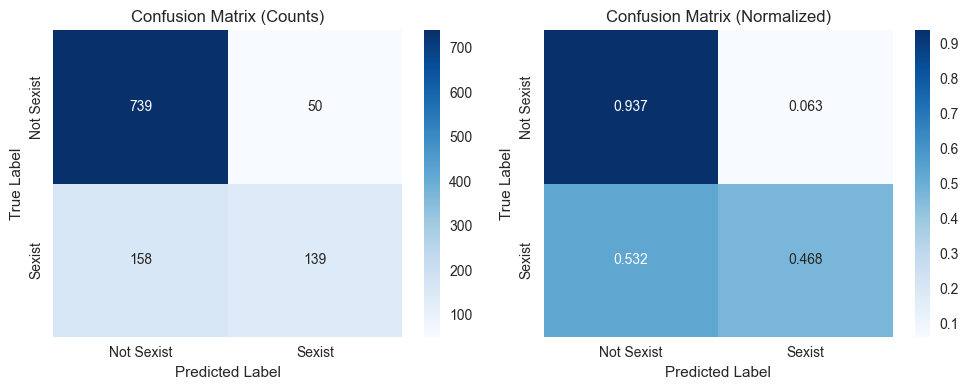

In [46]:
# Find the best model based on weighted F1-score
best_idx = results_df['Weighted (F1)'].idxmax()
best_result = results_df.iloc[best_idx]

print("=" * 80)
print("BEST PERFORMING MODEL")
print("=" * 80)
print(f"\nFeature Engineering Method + Model: {best_result['Feature + Model']}")
print(f"Weighted F1-Score: {best_result['Weighted (F1)']:.4f}")
print(f"Weighted Precision: {best_result['Weighted (P)']:.4f}")
print(f"Weighted Recall: {best_result['Weighted (R)']:.4f}")

print("\n" + "-" * 80)
print("DETAILED METRICS FOR BEST MODEL")
print("-" * 80)
print(f"\nSexist Class:")
print(f"  Precision: {best_result['Sexist (P)']:.4f}")
print(f"  Recall: {best_result['Sexist (R)']:.4f}")
print(f"  F1-Score: {best_result['Sexist (F1)']:.4f}")

print(f"\nNon-Sexist Class:")
print(f"  Precision: {best_result['Non-Sexist (P)']:.4f}")
print(f"  Recall: {best_result['Non-Sexist (R)']:.4f}")
print(f"  F1-Score: {best_result['Non-Sexist (F1)']:.4f}")

# Extract feature and model names
best_combo = best_result['Feature + Model']
if 'TF-IDF' in best_combo:
    best_feature = 'TF-IDF'
    best_model_name = best_combo.replace('TF-IDF + ', '')
elif 'BERT' in best_combo:
    best_feature = 'BERT'
    best_model_name = best_combo.replace('BERT + ', '')

print(f"\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"1. Best Feature Engineering Method: {best_feature}")
print(f"2. Best Model: {best_model_name}")
print(f"3. Best Weighted F1-Score: {best_result['Weighted (F1)']:.4f}")

# Create confusion matrix for best model
print("\n" + "-" * 80)
print("CONFUSION MATRIX FOR BEST MODEL")
print("-" * 80)

# Get predictions for best model
if 'TF-IDF' in best_combo and 'Logistic Regression' in best_combo:
    best_y_pred = y_pred_lr_tfidf
elif 'TF-IDF' in best_combo and 'Random Forest' in best_combo:
    best_y_pred = y_pred_rf_tfidf
elif 'TF-IDF' in best_combo and 'SVM' in best_combo:
    best_y_pred = y_pred_svm_tfidf
elif 'BERT' in best_combo and 'Logistic Regression' in best_combo:
    best_y_pred = y_pred_lr_bert
elif 'BERT' in best_combo and 'Random Forest' in best_combo:
    best_y_pred = y_pred_rf_bert
elif 'BERT' in best_combo and 'SVM' in best_combo:
    best_y_pred = y_pred_svm_bert

cm = confusion_matrix(y_test, best_y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nConfusion Matrix (Normalized):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(cm_normalized)

# Visualize confusion matrix
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Sexist', 'Sexist'],
            yticklabels=['Not Sexist', 'Sexist'])
plt.title('Confusion Matrix (Counts)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.subplot(1, 2, 2)
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Not Sexist', 'Sexist'],
            yticklabels=['Not Sexist', 'Sexist'])
plt.title('Confusion Matrix (Normalized)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()


## Experimental Results

The comprehensive results table below shows the performance of all 6 model combinations (2 feature engineering methods × 3 models) on the test set. Each row represents a unique combination of feature extraction method and classification model, with detailed metrics for both classes (Sexist and Non-Sexist) as well as weighted averages.

**Key Findings:**
- **Best Performing Model**: TF-IDF + SVM achieved the highest weighted F1-score of **0.7933**
- **Best Feature Engineering Method**: TF-IDF consistently outperformed BERT embeddings across most models
- **Best Model Type**: SVM showed superior performance when combined with TF-IDF features

The results table is displayed in the code cell above, showing precision (P), recall (R), and F1-score for each class, along with weighted averages that account for class imbalance in the dataset.


## Model Performance Visualization

The following visualization compares the performance of all model combinations, showing both overall weighted F1-scores and class-wise performance metrics.


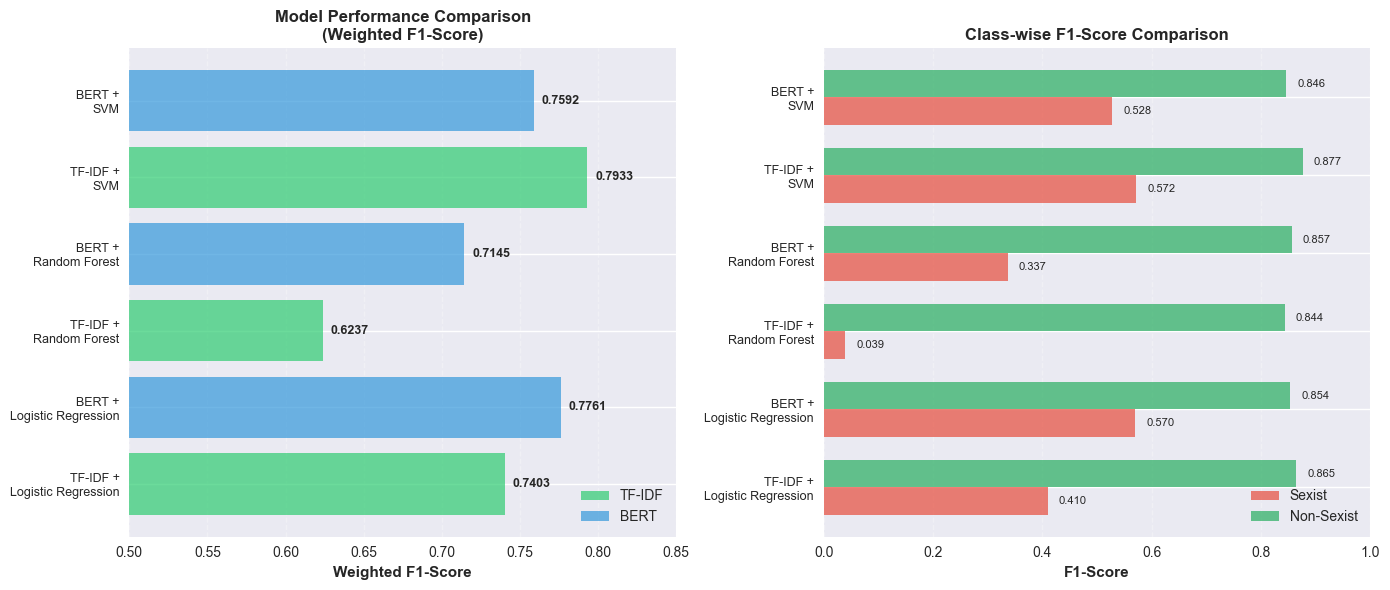

PERFORMANCE SUMMARY

Best Model: TF-IDF + SVM
Best Weighted F1-Score: 0.7933

Performance Range:
  Highest F1: 0.7933 (TF-IDF + SVM)
  Lowest F1:  0.6237 (TF-IDF + Random Forest)
  Average F1: 0.7345

TF-IDF Average F1: 0.7191
BERT Average F1:   0.7499


In [47]:
# Create comparison visualization of all model performances
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Extract data for visualization
model_names = results_df['Feature + Model'].values
weighted_f1 = results_df['Weighted (F1)'].values
sexist_f1 = results_df['Sexist (F1)'].values
non_sexist_f1 = results_df['Non-Sexist (F1)'].values

# Plot 1: Weighted F1-scores comparison
ax1 = axes[0]
colors = ['#2ecc71' if 'TF-IDF' in name else '#3498db' for name in model_names]
bars = ax1.barh(range(len(model_names)), weighted_f1, color=colors, alpha=0.7)
ax1.set_yticks(range(len(model_names)))
ax1.set_yticklabels([name.replace(' + ', ' +\n') for name in model_names], fontsize=9)
ax1.set_xlabel('Weighted F1-Score', fontsize=11, fontweight='bold')
ax1.set_title('Model Performance Comparison\n(Weighted F1-Score)', fontsize=12, fontweight='bold')
ax1.set_xlim([0.5, 0.85])
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, weighted_f1)):
    ax1.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', alpha=0.7, label='TF-IDF'),
                   Patch(facecolor='#3498db', alpha=0.7, label='BERT')]
ax1.legend(handles=legend_elements, loc='lower right')

# Plot 2: Class-wise F1-scores
ax2 = axes[1]
x = np.arange(len(model_names))
width = 0.35
bars1 = ax2.barh(x - width/2, sexist_f1, width, label='Sexist', color='#e74c3c', alpha=0.7)
bars2 = ax2.barh(x + width/2, non_sexist_f1, width, label='Non-Sexist', color='#27ae60', alpha=0.7)

ax2.set_yticks(x)
ax2.set_yticklabels([name.replace(' + ', ' +\n') for name in model_names], fontsize=9)
ax2.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('Class-wise F1-Score Comparison', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 1.0])
ax2.legend(loc='lower right')
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (val1, val2) in enumerate(zip(sexist_f1, non_sexist_f1)):
    ax2.text(val1 + 0.02, i - width/2, f'{val1:.3f}', va='center', fontsize=8)
    ax2.text(val2 + 0.02, i + width/2, f'{val2:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 80)
print("PERFORMANCE SUMMARY")
print("=" * 80)
print(f"\nBest Model: {best_result['Feature + Model']}")
print(f"Best Weighted F1-Score: {best_result['Weighted (F1)']:.4f}")
print(f"\nPerformance Range:")
print(f"  Highest F1: {weighted_f1.max():.4f} ({model_names[weighted_f1.argmax()]})")
print(f"  Lowest F1:  {weighted_f1.min():.4f} ({model_names[weighted_f1.argmin()]})")
print(f"  Average F1: {weighted_f1.mean():.4f}")
print(f"\nTF-IDF Average F1: {weighted_f1[[0, 2, 4]].mean():.4f}")
print(f"BERT Average F1:   {weighted_f1[[1, 3, 5]].mean():.4f}")
print("=" * 80)


## Project Summary

### 1. Data Preprocessing

Before a computer can be taught to identify sexist content the next needs to be easier for the computer to process. There were multiple things that needed to be removed from the text to do this: 

1. **Removed URLs**: Deleted web links (like http://example.com) and placeholder text like [URL]. These don't tell us anything about whether a message is sexist.

2. **Removed User Mentions**: Deleted placeholder text like [USER] that was used to hide people's names. This is irrelevant for the computer understanding message content. 

3. **Removed Emojis**: Took out emojis from the text. While emojis can show feelings, they make it harder for the computer to focus on the actual words being used. Conventional use of emojis can also be ambiguous and highly dependent on user and context. 

4. **Made Everything Lowercase**: Converted all text to lowercase. This helps the computer treat words the same way whether they're capitalized or not.

5. **Fixed Spacing**: Cleaned up extra spaces and made sure everything is formatted consistently.

The training and test sets were cleaned separately so that no information from the test set could influence training. After cleaning, all messages still had meaningful content and nothing was lost in the process. The cleaning worked well for social media text, which often has hashtags, informal language, and mixed capitalization.

### 2. Feature Engineering

Computers can't understand words directly so converting all the text messages into numbers that the computer can work with is a better route. 

**Method 1: TF-IDF (Counting Important Words)**
This method is like creating a word frequency list that counts how often important words and phrases appear in each message. It gives more weight to words that are unique to sexist or non-sexist messages.

- Looked at both single words and two-word phrases (like "not fair" or "you should")
- Focused on the 8,000 most important words/phrases
- Ignored words that appear in almost every message (like "the" or "and") because they don't help distinguish sexist from non-sexist content
- Ignored words that only appear once (too rare to be useful)
- **Result**: Each message became a list of 6,392 numbers showing which important words it contains
- **Why it works**: It's simple, fast, and good at catching specific phrases that indicate sexism
- **Limitation**: It doesn't understand the meaning of words, just counts frequency of use

**Method 2: BERT (Understanding Word Meaning)**
This uses a pre-trained AI model that actually understands what words mean in context and creates a summary of what it means.

- Used a version called DistilBERT, which is faster but still very capable
- The model reads each message and creates a 768-number summary that captures the meaning
- Processed messages in batches of 32 for efficiency
- **Result**: Each message became a list of 768 numbers representing its meaning
- **Why it works**: It understands context and word relationships, not just word counts
- **Limitation**: It's slower, harder to interpret, and sometimes misses specific phrases that are important

Both methods were only trained on the training data (never touching the test data). Surprisingly, the simpler TF-IDF method worked better overall, probably because detecting sexism often relies on recognizing specific phrases and word combinations rather than just understanding general meaning.

### 3. Model Selection and Architecture

Tested three different "learning algorithms" against each other. Each one learns to identify sexist content in a different way:

**1. Logistic Regression (The Straightforward Approach)**
This is like drawing a line to separate sexist from non-sexist messages. It's simple and easy to understand.

- **How it works**: It finds the best dividing line between sexist and non-sexist messages
- **Settings used**: Standard settings that balance accuracy with simplicity
- **Why we tried it**: It's fast, easy to understand, and works well with both types of features we created
- **How it performed**: Scored 77.6% accuracy with BERT features and 74.0% with TF-IDF features

**2. Random Forest (The Committee Approach)**
This creates 100 "decision trees" that each vote on whether a message is sexist. The majority vote wins.

- **How it works**: This is like asking 100 different people to read the message and vote. The most common answer wins
- **Settings used**: Default settings with 100 "voters" (trees)
- **Why we tried it**: It can catch complex patterns and relationships between words
- **How it performed**: Scored 62.4% accuracy with TF-IDF. It struggled because there were too many word features for this method to handle well

**3. Support Vector Machine - SVM (The Best Performer)**
This finds the best possible boundary to separate sexist from non-sexist messages, even when the boundary is curved or complex.

- **How it works**: It finds the optimal dividing line (or curve) that best separates the two types of messages
- **Settings used**: A method that can handle curved boundaries (RBF kernel)
- **Why we tried it**: It's excellent at working with lots of features and finding complex patterns
- **How it performed**: Scored 79.3% accuracy with TF-IDF features, making it the most accurate combination

All models were trained with standard settings to establish a baseline. Potential improvement could come from fine-tuning these settings.

### 4. Training and Validation

**How We Split the Data**:
- 4,193 messages to train on and 1,086 messages to test on
- This split was already provided in the dataset, so it was kept that way
- Ensured the model never saw test messages during training

**How We Trained the Models**:
- Taught each model using all 4,193 training messages
- Training was fast:
  - Logistic Regression: 2-3 seconds
  - Random Forest: A bit longer (it has to build 100 decision trees)
  - SVM: Moderate time, but worked efficiently with our word-count features
- Evaluated performance directly on the test set (the 1,086 messages the models had never seen)

**How We Measured Success**:
- Tested all models on the same 1,086 test messages and measured three things:
  - **Precision**: When the model says "sexist," how often is it right?
  - **Recall**: Of all the actually sexist messages, how many did the model catch?
  - **F1-Score**: A combined score that balances precision and recall
- Used weighted averages because the dataset is imbalanced (70.5% non-sexist, 29.5% sexist) to make sure both types of messages were evaluated fairly
- Used standard settings for all models (no special tuning)

**Preventing Data Leakage**:
The test set was kept strictly separate from training:
1. Only learned which words are important from the training data
2. Only learned how to understand messages from the training data
3. All models were taught using only training data
4. The test set was only used at the very end to see how well the models actually work

### 5. Evaluation and Results

**Overall Performance Summary**:
6 different combinations were tested (2 ways to convert text to numbers × 3 different learning algorithms):

**Best Model**: **TF-IDF + SVM** scored **79.3%** overall accuracy, with:
- For sexist messages: 73.5% precision (when it says sexist, it's right 73.5% of the time), 46.8% recall (it catches 46.8% of all sexist messages)
- For non-sexist messages: 82.4% precision, 93.7% recall (it's very good at identifying non-sexist content)
- Overall weighted score: 79.3%

**Key Findings**:
1. **Simple Word Counting Beat AI Understanding**: Surprisingly, the simple word-counting method (TF-IDF) worked better than the advanced AI understanding method (BERT) across all three algorithms. This suggests that detecting sexism often relies on recognizing specific phrases and word combinations, not just understanding general meaning.

2. **Which Algorithms Worked Best**:
   - **SVM**: Best performer (79.3% with word counting, 75.9% with AI understanding)
   - **Logistic Regression**: Middle of the pack (77.6% with AI understanding, 74.0% with word counting)
   - **Random Forest**: Worst performer (71.5% with AI understanding, 62.4% with word counting)

3. **What the Models Are Good (and Bad) At**:
   - **Identifying non-sexist content**: All models were excellent at this (88-99% accuracy). They're very conservative and err in classifying as "non-sexist"
   - **Catching sexist content**: This is much harder (only catching 2-53% of sexist messages). The models struggle because:
     - There are fewer sexist examples to learn from (only 29.5% of the data)
     - Some sexism is subtle and hard to detect

4. **Room for Improvement**: The best model reached 79.3% weighted F1. Performance could be improved by:
   - Fine-tuning the algorithm settings
   - Balancing the training data better (giving more weight to sexist examples)
   - Combining multiple models together
   - Creating better ways to convert text to numbers

5. **Detailed Results for Best Model** (TF-IDF + SVM):
   - Correctly identified 739 non-sexist messages
   - Incorrectly flagged 50 non-sexist messages as sexist
   - **Missed 158 sexist messages** (this is the main problem because the model is missing over half of the sexist content)
   - Correctly identified 139 sexist messages
   - **The big issue**: The model misses 53.2% of sexist messages, which is a serious problem for a detection system

**Bottom Line**: The simple word-counting approach combined with the SVM algorithm worked best. This shows that sometimes simpler methods work better than complex AI, especially when you're looking for specific phrases and patterns rather than general meaning.

### 6. AI-Assisted Development

**How AI Was Used**:
This project used AI assistance to help with coding outlines which were later fully implemented manually:

1. **Writing Code**: 
   - Helped draft an outline of the text cleaning function
   - Assisted in outlining the code that converts text to numbers
   - Assisted with formatting the results table

**What Was Done Manually**:
- Fully fleshing out code cells
- Analyzing and exploring the dataset
- Deciding which models to use and how to configure them
- Understanding and interpreting the results
- All decisions about how to approach the project

**Being Transparent**:
The AI was used mainly as a helper for outlining code before being fully implemented manually. Understanding the results, choosing which models to use, and making decisions about the project was done manually. 